<a href="https://colab.research.google.com/github/meytriangg/Data-Mining-Course/blob/main/CLUSTERING_MEY.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



> Mey Tri Anggraheni 2304020067


# **Weather Data Clustering for Pattern Identification**

Weather data consists of multiple variables such as temperature, humidity, wind speed, and other atmospheric conditions, which often create complex patterns that are difficult to interpret directly. Therefore, an analytical approach is needed to simplify the data and uncover hidden structures. In this study, clustering is applied as an unsupervised learning method to group data based on similarity without predefined labels, allowing natural patterns to emerge from the dataset.

The dataset used contains several weather-related attributes that represent different environmental conditions. Through the clustering process, the data will be grouped into distinct categories with similar characteristics. The objective of this approach is to identify meaningful weather patterns, simplify complex data into more understandable groups, and provide insights that can support further analysis and decision-making.

DATASET DESCRIPTION

Each row in minute_weather.csv contains weather data captured for a one-minute interval. Each row, or sample, consists of the following variables:

rowID: unique number for each row (Unit: NA)

hpwren_timestamp: timestamp of measure (Unit: year-month-day hour:minute:second)

air_pressure: air pressure measured at the timestamp (Unit: hectopascals)

air_temp: air temperature measure at the timestamp (Unit: degrees Fahrenheit)

avg_wind_direction: wind direction averaged over the minute before the timestamp (Unit: degrees, with 0 means coming from the North, and increasing clockwise)

avg_wind_speed: wind speed averaged over the minute before the timestamp (Unit: meters per second)

max_wind_direction: highest wind direction in the minute before the timestamp (Unit: degrees, with 0 being North and increasing clockwise)

max_wind_speed: highest wind speed in the minute before the timestamp (Unit: meters per second)

min_wind_direction: smallest wind direction in the minute before the timestamp (Unit: degrees, with 0 being North and inceasing clockwise)

min_wind_speed: smallest wind speed in the minute before the timestamp (Unit: meters per second)

rain_accumulation: amount of accumulated rain measured at the timestamp (Unit: millimeters)

rain_duration: length of time rain has fallen as measured at the timestamp (Unit: seconds)

relative_humidity: relative humidity measured at the timestamp (Unit: percent)

**PREPROCESSING DATA**

In [4]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
df = pd.read_csv('minute_weather.csv')
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1321148 entries, 0 to 1321147
Data columns (total 13 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   rowID               1321148 non-null  int64  
 1   hpwren_timestamp    1321148 non-null  object 
 2   air_pressure        1321148 non-null  float64
 3   air_temp            1321148 non-null  float64
 4   avg_wind_direction  1320782 non-null  float64
 5   avg_wind_speed      1320782 non-null  float64
 6   max_wind_direction  1320782 non-null  float64
 7   max_wind_speed      1320782 non-null  float64
 8   min_wind_direction  1320782 non-null  float64
 9   min_wind_speed      1320781 non-null  float64
 10  rain_accumulation   1321146 non-null  float64
 11  rain_duration       1321146 non-null  float64
 12  relative_humidity   1321147 non-null  float64
dtypes: float64(11), int64(1), object(1)
memory usage: 131.0+ MB


,rowID,air_pressure,air_temp,avg_wind_direction,avg_wind_speed,max_wind_direction,max_wind_speed,min_wind_direction,min_wind_speed,rain_accumulation,rain_duration,relative_humidity
count,1.321148e+06,1.321148e+06,1.321148e+06,1.320782e+06,1.320782e+06,1.320782e+06,1.320782e+06,1.320782e+06,1.320781e+06,1.321146e+06,1.321146e+06,1.321147e+06
mean,6.605735e+05,9.169409e+02,6.103018e+01,1.596127e+02,2.803202e+00,1.605527e+02,3.437611e+00,1.650242e+02,2.154402e+00,7.986021e-04,4.981054e-01,4.748323e+01
std,3.813827e+05,3.164689e+00,1.192499e+01,9.659517e+01,2.090028e+00,9.328937e+01,2.459208e+00,9.926671e+01,1.767594e+00,4.862205e-01,4.116922e+01,2.661168e+01
min,0.000000e+00,9.050000e+02,3.164000e+01,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.400000e+00
25%,3.302868e+05,9.149000e+02,5.198000e+01,5.900000e+01,1.300000e+00,6.600000e+01,1.600000e+00,6.600000e+01,8.000000e-01,0.000000e+00,0.000000e+00,2.400000e+01
50%,6.605735e+05,9.168000e+02,6.098000e+01,1.810000e+02,2.200000e+00,1.850000e+02,2.800000e+00,1.790000e+02,1.700000e+00,0.000000e+00,0.000000e+00,4.380000e+01
75%,9.908602e+05,9.190000e+02,6.998000e+01,2.170000e+02,3.800000e+00,2.230000e+02,4.600000e+00,2.120000e+02,3.000000e+00,0.000000e+00,0.000000e+00,6.890000e+01
max,1.321147e+06,9.295000e+02,9.950000e+01,3.590000e+02,3.230000e+01,3.590000e+02,3.600000e+01,3.590000e+02,3.200000e+01,5.563700e+02,3.487100e+04,9.300000e+01


In [6]:
print("\nMissing Values:")
print(df.isnull().sum())

# Hapus data yang memiliki missing value
df = df.dropna()

# ==============================
# 5. Drop Kolom Tidak Relevan
# ==============================
cols_to_drop = ['rowID', 'timestamp', 'date']
df = df.drop(columns=[col for col in cols_to_drop if col in df.columns])

print("\nKolom setelah drop:")
print(df.columns)

# ==============================
# 6. Ambil Data Numerik
# ==============================
df_numeric = df.select_dtypes(include=[np.number])

print("\nData Numerik:")
print(df_numeric.head())

# ==============================
# 7. Scaling (Standardization)
# ==============================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_numeric)

# ==============================
# 8. Hasil Akhir
# ==============================
print("\nData setelah scaling (5 baris pertama):")
print(X_scaled[:5])


Missing Values:
rowID                 0
hpwren_timestamp      0
air_pressure          0
air_temp              0
avg_wind_direction    0
avg_wind_speed        0
max_wind_direction    0
max_wind_speed        0
min_wind_direction    0
min_wind_speed        0
rain_accumulation     0
rain_duration         0
relative_humidity     0
dtype: int64

Kolom setelah drop:
Index(['hpwren_timestamp', 'air_pressure', 'air_temp', 'avg_wind_direction',
       'avg_wind_speed', 'max_wind_direction', 'max_wind_speed',
       'min_wind_direction', 'min_wind_speed', 'rain_accumulation',
       'rain_duration', 'relative_humidity'],
      dtype='object')

Data Numerik:
   air_pressure  air_temp  avg_wind_direction  avg_wind_speed  \
1         912.3     63.86               161.0             0.8   
2         912.3     64.22                77.0             0.7   
3         912.3     64.40                89.0             1.2   
4         912.3     64.40               185.0             0.4   
5         912.3    

**CLUSTERING**

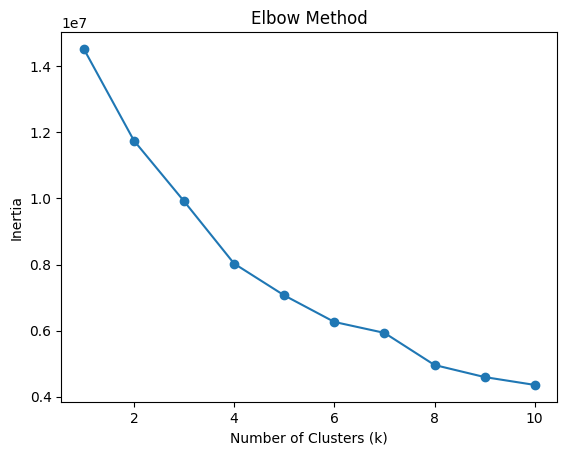

In [7]:

#  Menentukan jumlah cluster (Elbow Method)
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

K_range = range(1, 11)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Plot Elbow
plt.figure()
plt.plot(K_range, inertia, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

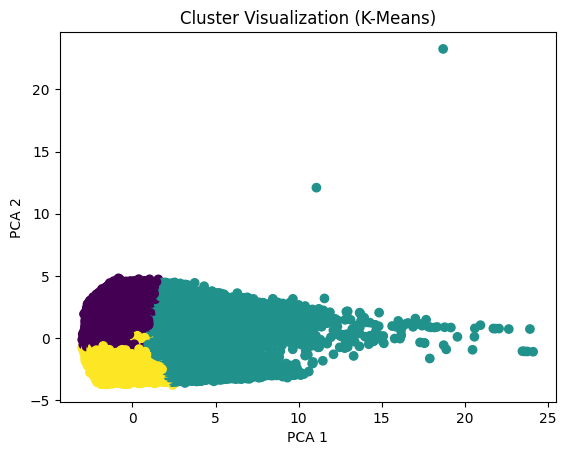

In [9]:
kmeans = KMeans(n_clusters=3, random_state=42)
labels = kmeans.fit_predict(X_scaled)
df_numeric['Cluster'] = labels
df_numeric.head()

from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure()
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels)
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.title('Cluster Visualization (K-Means)')
plt.show()

In [11]:
cluster_summary = df_numeric.groupby('Cluster').mean()
print(cluster_summary)

         air_pressure   air_temp  avg_wind_direction  avg_wind_speed  \
Cluster                                                                
0          916.715079  62.273957          228.533713        1.924211   
1          915.830118  54.804521          165.366468        6.016170   
2          918.068502  63.440729           48.017838        1.935198   

         max_wind_direction  max_wind_speed  min_wind_direction  \
Cluster                                                           
0                214.482161        2.435630          212.177887   
1                175.041341        7.140541          154.820902   
2                 66.268991        2.419987           98.532738   

         min_wind_speed  rain_accumulation  rain_duration  relative_humidity  
Cluster                                                                       
0              1.400065           0.000156       0.255281          50.252737  
1              4.839611           0.003310       1.549298         